In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("All libraries loaded!")


All libraries loaded!


In [4]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\archive (2)\Road Accident Data.csv")

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (307973, 21)

Columns: ['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [7]:
# Check missing values and data types
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nAccident Severity values:")
print(df['Accident_Severity'].value_counts())

Missing values:
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64

Data types:
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail              

In [8]:
# Fix "Fetal" typo to "Fatal"
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

# Drop Carriageway_Hazards (too many missing)
df = df.drop(columns=['Carriageway_Hazards'])

# Fill missing values with mode
df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].fillna(df['Road_Surface_Conditions'].mode()[0])
df['Road_Type'] = df['Road_Type'].fillna(df['Road_Type'].mode()[0])
df['Weather_Conditions'] = df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0])
df['Time'] = df['Time'].fillna(df['Time'].mode()[0])

# Convert Date to datetime
df['Accident Date'] = pd.to_datetime(df['Accident Date'])
df['Month'] = df['Accident Date'].dt.month
df['Year'] = df['Accident Date'].dt.year

print("Cleaning done!")
print("Missing values remaining:")
print(df.isnull().sum().sum())
print("\nSeverity values after fix:")
print(df['Accident_Severity'].value_counts())

Cleaning done!
Missing values remaining:
0

Severity values after fix:
Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64


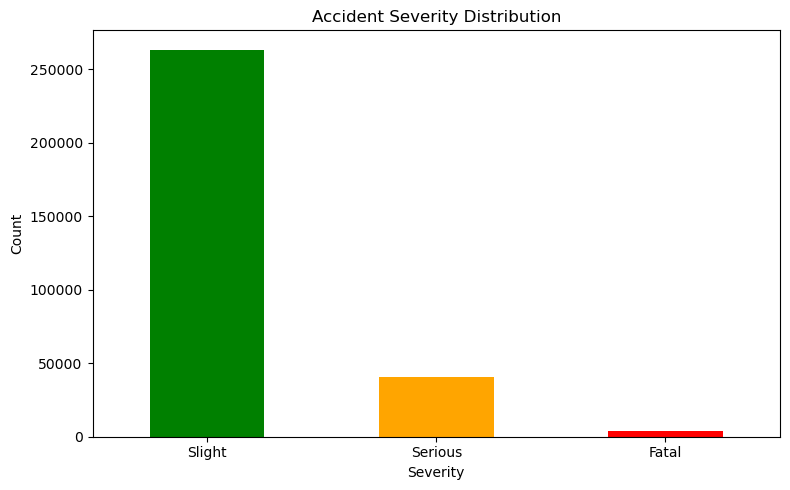

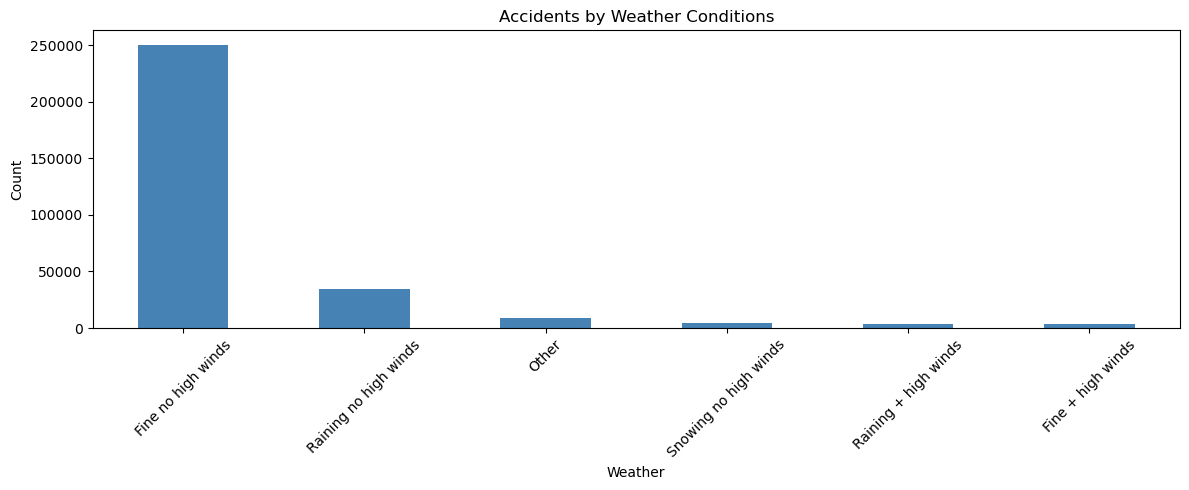

In [9]:
# Severity distribution
plt.figure(figsize=(8,5))
df['Accident_Severity'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Accidents by Weather
plt.figure(figsize=(12,5))
df['Weather_Conditions'].value_counts().head(6).plot(kind='bar', color='steelblue')
plt.title('Accidents by Weather Conditions')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

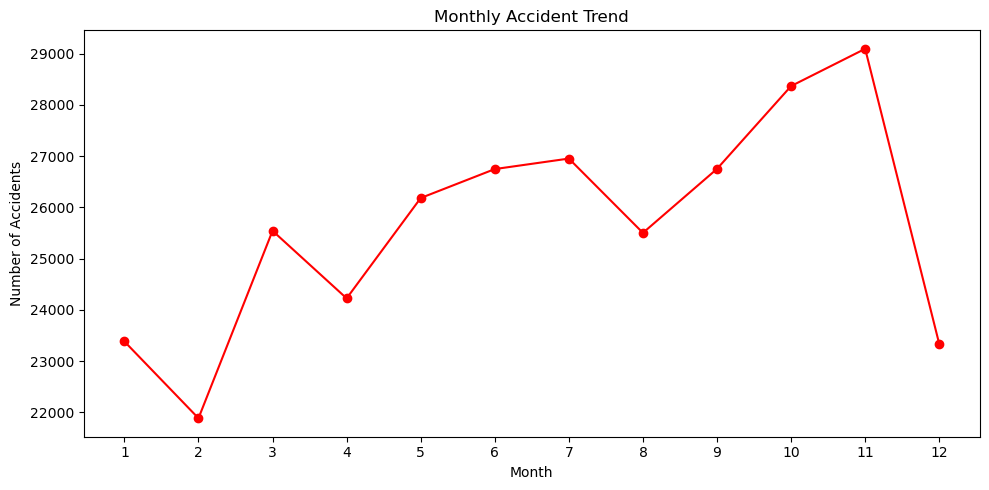

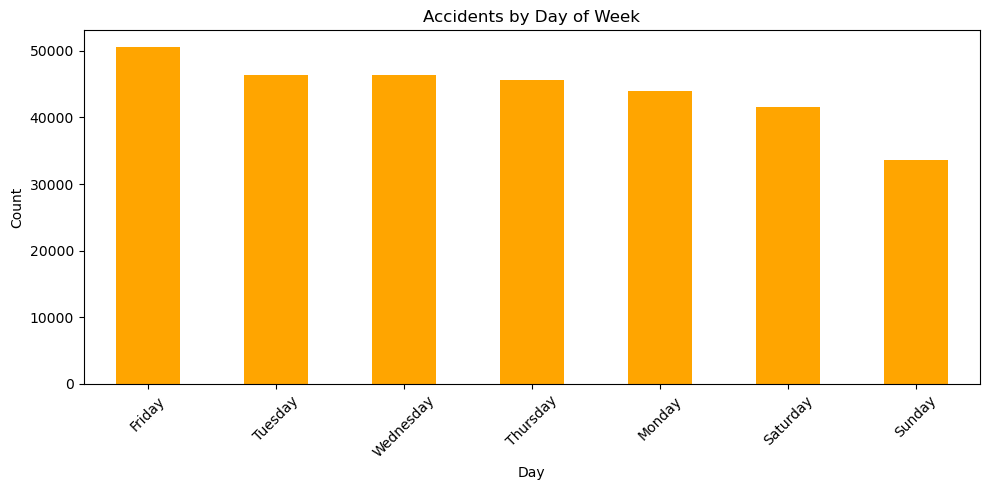

In [10]:
# Accidents by Month
plt.figure(figsize=(10,5))
df.groupby('Month')['Accident_Index'].count().plot(kind='line', marker='o', color='red')
plt.title('Monthly Accident Trend')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

# Accidents by Day of Week
plt.figure(figsize=(10,5))
df['Day_of_Week'].value_counts().plot(kind='bar', color='orange')
plt.title('Accidents by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



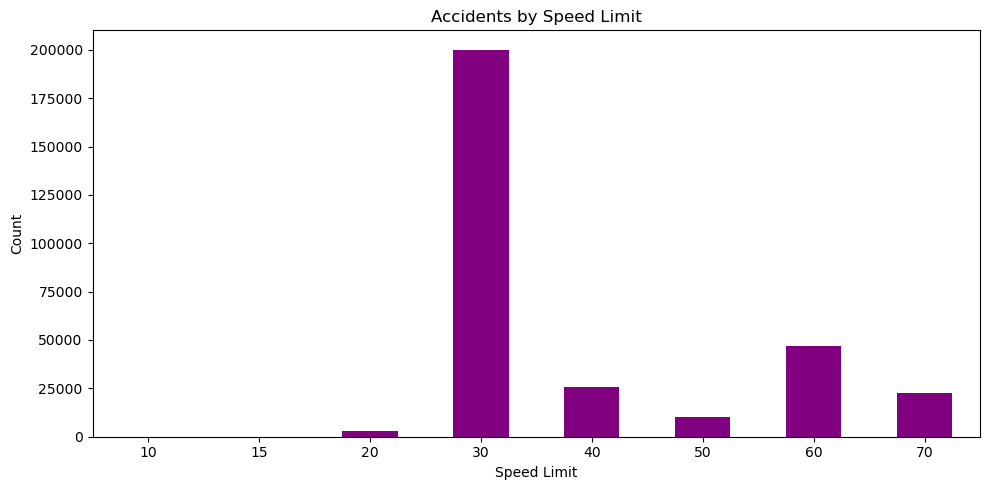

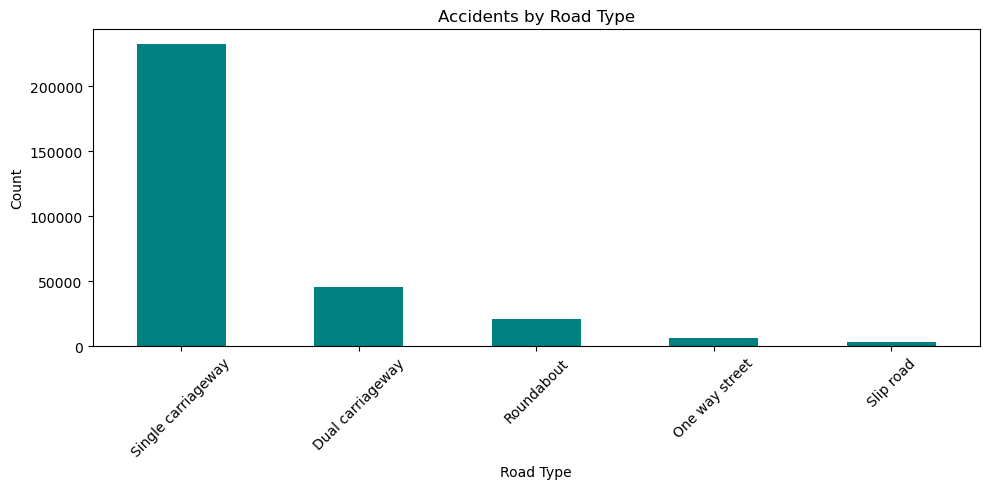

In [11]:
# Accidents by Speed Limit
plt.figure(figsize=(10,5))
df.groupby('Speed_limit')['Accident_Index'].count().plot(kind='bar', color='purple')
plt.title('Accidents by Speed Limit')
plt.xlabel('Speed Limit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Accidents by Road Type
plt.figure(figsize=(10,5))
df['Road_Type'].value_counts().plot(kind='bar', color='teal')
plt.title('Accidents by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Prepare data for ML
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Select features
features = ['Day_of_Week', 'Speed_limit', 'Road_Type', 
            'Weather_Conditions', 'Light_Conditions',
            'Road_Surface_Conditions', 'Urban_or_Rural_Area',
            'Number_of_Vehicles', 'Month']

target = 'Accident_Severity'

# Copy dataframe
df_ml = df[features + [target]].copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

print("Data prepared for ML!")
print(df_ml.shape)

Data prepared for ML!
(307973, 10)


In [16]:
# Split data
X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8438184917606949

Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.00      0.00       831
           1       0.18      0.02      0.04      8101
           2       0.86      0.98      0.92     52663

    accuracy                           0.84     61595
   macro avg       0.35      0.34      0.32     61595
weighted avg       0.76      0.84      0.79     61595



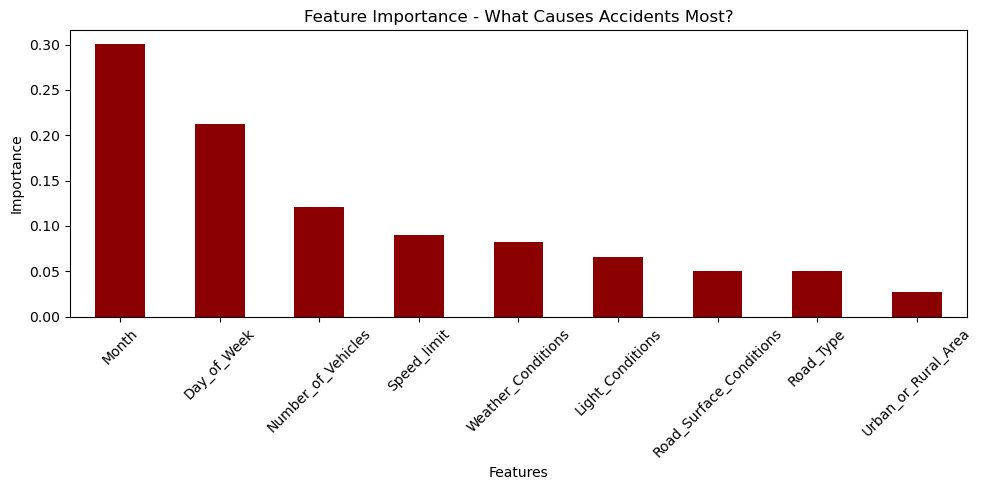


Top factors causing accidents:
Month                      0.300774
Day_of_Week                0.212415
Number_of_Vehicles         0.120589
Speed_limit                0.090443
Weather_Conditions         0.082785
Light_Conditions           0.065659
Road_Surface_Conditions    0.050328
Road_Type                  0.050261
Urban_or_Rural_Area        0.026746
dtype: float64


In [17]:
# Feature Importance
feat_importance = pd.Series(model.feature_importances_, index=features)

plt.figure(figsize=(10,5))
feat_importance.sort_values(ascending=False).plot(kind='bar', color='darkred')
plt.title('Feature Importance - What Causes Accidents Most?')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop factors causing accidents:")
print(feat_importance.sort_values(ascending=False))

In [18]:
import joblib

# Save model
joblib.dump(model, 'accident_severity_model.pkl')
print("Model saved!")

Model saved!


In [20]:
import mysql.connector

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Rohith@030705'
)

cursor = conn.cursor()

# Create Database
cursor.execute("CREATE DATABASE IF NOT EXISTS accident_analysis")
cursor.execute("USE accident_analysis")

print("Database created!")

Database created!


In [21]:
# Use accident_analysis database
cursor.execute("USE accident_analysis")

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS accidents (
    accident_index VARCHAR(20),
    accident_date VARCHAR(20),
    day_of_week VARCHAR(20),
    junction_control VARCHAR(50),
    junction_detail VARCHAR(50),
    accident_severity VARCHAR(20),
    latitude FLOAT,
    light_conditions VARCHAR(50),
    local_authority VARCHAR(50),
    longitude FLOAT,
    number_of_casualties INT,
    number_of_vehicles INT,
    police_force VARCHAR(50),
    road_surface VARCHAR(50),
    road_type VARCHAR(50),
    speed_limit INT,
    time VARCHAR(10),
    urban_or_rural VARCHAR(20),
    weather_conditions VARCHAR(50),
    vehicle_type VARCHAR(50),
    month INT,
    year INT
)
""")

print("Table created!")

Table created!


In [22]:
# Import data to MySQL
conn.database = 'accident_analysis'

for index, row in df.iterrows():
    cursor.execute("""
        INSERT INTO accidents VALUES 
        (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """, (
        row['Accident_Index'],
        str(row['Accident Date']),
        row['Day_of_Week'],
        row['Junction_Control'],
        row['Junction_Detail'],
        row['Accident_Severity'],
        row['Latitude'],
        row['Light_Conditions'],
        row['Local_Authority_(District)'],
        row['Longitude'],
        row['Number_of_Casualties'],
        row['Number_of_Vehicles'],
        row['Police_Force'],
        row['Road_Surface_Conditions'],
        row['Road_Type'],
        row['Speed_limit'],
        row['Time'],
        row['Urban_or_Rural_Area'],
        row['Weather_Conditions'],
        row['Vehicle_Type'],
        row['Month'],
        row['Year']
    ))

conn.commit()
print(f"Done! {len(df)} rows inserted!")

Done! 307973 rows inserted!
